# Contexte
Une entreprise souhaite développer un système d’intelligence artificielle capable de reconnaître
automatiquement le type de déchet présent sur une photographie afin d'améliorer le tri des
déchets.
Le modèle devra classer chaque image dans l'une des catégories suivantes :

cardboard : cartons ondulés, cartons plats, …

plastic : bouteilles, emballages plastiques...

paper : feuilles, journaux...

glass : bouteilles et objets en verre...

metal : canettes, boîtes métalliques...

trash : emballages bonbons, tasses jetables, ...

Le problème est que les images collectées proviennent de plusieurs sources. Elles ne sont donc pas
homogènes : dimensions différentes ; formats différents ; images RGB et grayscale ; certaines images
sont trop petites ; certaines images sont corrompues ; quelques images sont vides ; images
dupliquées ; quelques images placées dans le mauvais dossier ; classes déséquilibrées.

L'objectif de l'atelier est donc de construire un jeu de données images propre et homogène, prêt à
être utilisé pour entraîner un modèle de Machine Learning ou de Deep Learning.

In [94]:
# Importation des bibliotheque
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm.auto import tqdm
from PIL import Image
from pathlib import Path
import hashlib
import math



# Partie 1 – Exploration du dataset
Développer un programme Python capable de récupérer, pour chaque image, son nom, sa classe,
son format, son mode, sa largeur, sa hauteur, l’écart-type de ses pixels, son nombre de canaux et sa
taille.
NB : prendre en charge aussi les fichiers corrompus

In [95]:
# Liste de tous les chemain de fichiers
RAW_DIR = Path("../data/raw")

fichiers = []
for dossier_classe in sorted(RAW_DIR.iterdir()):
    if dossier_classe.is_dir():
        for fichier in sorted(dossier_classe.iterdir()):
            if fichier.is_file():
                fichiers.append(fichier)

print(len(fichiers), "fichiers trouvés")
print(fichiers[0:2])


1032 fichiers trouvés
[PosixPath('../data/raw/cardboard/cardboard1.jpg'), PosixPath('../data/raw/cardboard/cardboard10.jpg')]


In [96]:
# fonction inspection de l'image
def inspect_image(chemin):
    # 1) La fiche : les infos qu'on peut toujours obtenir, le reste à None
    fiche = {
        "name": chemin.name,
        "class": chemin.parent.name,
        "format": None,
        "mode": None,
        "width": None,
        "height": None,
        "channels": None,
        "pixel_std": None,
        "file_size_kb": round(chemin.stat().st_size / 1024, 2),
        "corrupted": False,
    }

    # 2) On essaie de lire l'image
    try:
        with Image.open(chemin) as img:
            img.load()                                   # lit tous les pixels
            fiche["format"] = img.format
            fiche["mode"] = img.mode
            fiche["width"] = img.width
            fiche["height"] = img.height
            fiche["channels"] = len(img.getbands())
            gris = np.asarray(img.convert("L"))
            fiche["pixel_std"] = float(gris.std())

    # 3) Si une erreur se produit, l'image est corrompue
    except Exception as e:
        fiche["corrupted"] = True

    return fiche

In [97]:
toutes_les_fiches = []

for f in tqdm (fichiers):
    fiche = inspect_image(f)
    toutes_les_fiches.append(fiche)

print(len(toutes_les_fiches), "fiches creees")

  0%|          | 0/1032 [00:00<?, ?it/s]

1032 fiches creees


In [98]:
df = pd.DataFrame(toutes_les_fiches)
for colonne in ["width", "height","channels"]:
    df[colonne] = df[colonne].astype("Int64")
df.head(636)

,name,class,format,mode,width,height,channels,pixel_std,file_size_kb,corrupted
0,cardboard1.jpg,cardboard,JPEG,RGB,512,384,3,31.875892,16.93,False
1,cardboard10.jpg,cardboard,JPEG,RGB,512,384,3,38.799907,21.17,False
2,cardboard100.jpg,cardboard,JPEG,RGB,512,384,3,44.498372,14.54,False
3,cardboard101.jpg,cardboard,JPEG,RGB,512,384,3,68.561937,13.95,False
4,cardboard102.jpg,cardboard,JPEG,RGB,512,384,3,45.320633,17.59,False
...,...,...,...,...,...,...,...,...,...,...
631,paper211.jpg,paper,JPEG,RGB,512,384,3,29.630460,16.90,False
632,paper212.jpg,paper,JPEG,RGB,512,384,3,28.926619,11.68,False
633,paper213.jpg,paper,NaN,NaN,<NA>,<NA>,<NA>,NaN,7.12,True
634,paper214.jpg,paper,JPEG,RGB,512,384,3,63.676604,47.69,False


# Partie 2 – Détecter les images corrompues
Écrire et se servir d’une fonction qui détecte une image corrompue.

In [99]:
def is_corrupted_image(chemin):
    try:
        # le fichier est-il vide ? 
        if chemin.stat().st_size == 0:
            return True, "fichier vide (0 octet)"
        
        # la structure du fichier est-elle coherente?
        with Image.open(chemin) as img: 
            img.verify()
        # Peut-on lire tous les pixels?
        with Image.open(chemin) as img:
            img.load()

        return False, ""  # L'image est valide
    
    except Exception as e:
        print(f"Erreur lors de l'ouverture de l'image {chemin} : {e}")
        return True, str(e)[:100]


In [100]:
resultats = [is_corrupted_image(f) for f in tqdm(fichiers)]

df["is_corrupted_image"] = [r[0] for r in resultats]    # les True / False
df["motif"] = [r[1] for r in resultats]           # les messages d'erreur

  0%|          | 0/1032 [00:00<?, ?it/s]

Erreur lors de l'ouverture de l'image ../data/raw/cardboard/cardboard83.jpg : cannot identify image file '../data/raw/cardboard/cardboard83.jpg'
Erreur lors de l'ouverture de l'image ../data/raw/glass/glass74.jpg : Truncated File Read
Erreur lors de l'ouverture de l'image ../data/raw/metal/metal48.jpg : cannot identify image file '../data/raw/metal/metal48.jpg'
Erreur lors de l'ouverture de l'image ../data/raw/paper/paper213.jpg : cannot identify image file '../data/raw/paper/paper213.jpg'
Erreur lors de l'ouverture de l'image ../data/raw/plastic/plastic13.jpg : cannot identify image file '../data/raw/plastic/plastic13.jpg'
Erreur lors de l'ouverture de l'image ../data/raw/trash/trash3.jpg : cannot identify image file '../data/raw/trash/trash3.jpg'


In [101]:
n = df["is_corrupted_image"].sum()
print(f"Images corrompues : {n} / {len(df)} ({100 * n / len(df):.2f} %)")

# Le détail des fichiers corrompus
df[df["is_corrupted_image"]][["name", "class", "file_size_kb", "motif"]]

Images corrompues : 6 / 1032 (0.58 %)


,name,class,file_size_kb,motif
147,cardboard83.jpg,cardboard,20.40,cannot identify image file '../data/raw/cardbo...
326,glass74.jpg,glass,7.02,Truncated File Read
446,metal48.jpg,metal,7.09,cannot identify image file '../data/raw/metal/...
633,paper213.jpg,paper,7.12,cannot identify image file '../data/raw/paper/...
791,plastic13.jpg,plastic,5.13,cannot identify image file '../data/raw/plasti...
1004,trash3.jpg,trash,8.98,cannot identify image file '../data/raw/trash/...


# Partie 3 – Détecter les images vides
Écrire et se servir d’une fonction qui détecte les images vides : image entièrement noire, image
entièrement blanche ou image dont les pixels présentent très peu de variation.

On fixe un seuil : en dessous de 5 (sur une échelle de 0 à 255), l'image est considérée comme vide. Pour savoir de quel type de vide il s'agit, on regarde la moyenne des pixels :


| Écart-type | Moyenne | Diagnostic |
| :--- | :--- | :--- |
| ≥ 5 | (peu importe) | Image normale |
| < 5 | ≤ 10 (proche de 0) | Image noire |
| < 5 | ≥ 245 (proche de 255) | Image blanche |
| < 5 | Entre les deux | Faible variation (gris ou couleur unie) |


In [102]:
SEUIL_STD = 5      # en dessous, l'image est considérée comme vide

def is_empty_image(chemin, seuil=SEUIL_STD):
    """Retourne (vide, type, écart-type). Type : 'noire', 'blanche', 'faible_variation' ou ''."""
    with Image.open(chemin) as img:
        gris = np.asarray(img.convert("L"), dtype=np.float32)   # tableau de pixels en gris

    ecart_type = float(gris.std())
    moyenne = float(gris.mean())

    if ecart_type >= seuil:
        return False, "", ecart_type          # image normale
    if moyenne <= 10:
        return True, "noire", ecart_type
    if moyenne >= 245:
        return True, "blanche", ecart_type
    return True, "faible_variation", ecart_type

In [103]:
df["is_empty"] = False
df["empty_type"] = ""

for i in tqdm(df.index):
    if df.at[i, "is_corrupted_image"]:          # image illisible : on passe
        continue
    vide, type_vide, _ = is_empty_image(fichiers[i])
    df.at[i, "is_empty"] = vide
    df.at[i, "empty_type"] = type_vide

  0%|          | 0/1032 [00:00<?, ?it/s]

In [104]:
print("Images quasi vides :", df["is_empty"].sum())
print(df[df["is_empty"]]["empty_type"].value_counts())
df[df["is_empty"]][["name", "class", "empty_type", "pixel_std"]]

Images quasi vides : 4
empty_type
blanche    2
noire      2
Name: count, dtype: int64


,name,class,empty_type,pixel_std
167,image-blanche-512x384.jpg,cardboard,blanche,1.132032
355,image-noire-512x384.png,glass,noire,0.000000
357,image-blanche-512x384.jpg,metal,blanche,1.132032
358,image-noire-512x384.png,metal,noire,0.000000


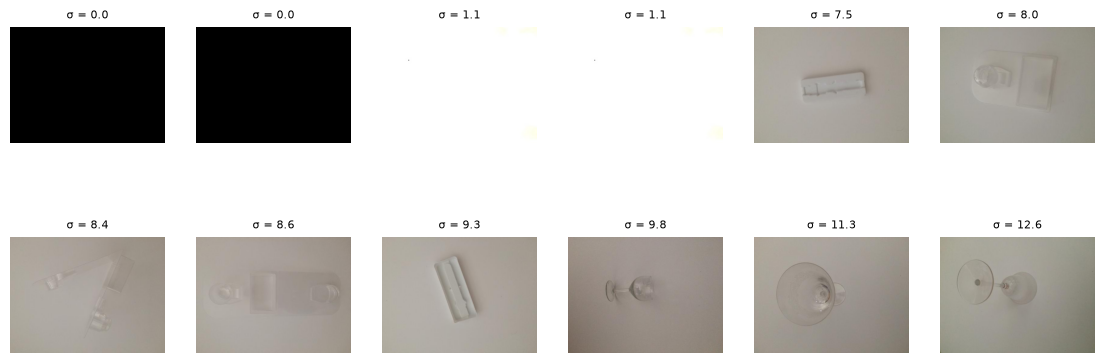

In [105]:
#verification

valides = df[~df["is_corrupted_image"]]

plus_bas = valides.nsmallest(12, "pixel_std")       # les 12 plus petits écarts-types

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, (i, ligne) in zip(axes.ravel(), plus_bas.iterrows()):
    ax.imshow(Image.open(fichiers[i]).convert("RGB"))
    ax.set_title(f"σ = {ligne['pixel_std']:.1f}", fontsize=8)
    ax.axis("off")
plt.show()

# Partie 4 – Détecter les différences de résolution

## 1) Déterminer la résolution minimale, la résolution maximale, les résolutions les plus fréquentes et le nombre d'images par résolution.

In [106]:
# Preparation des donnees
valides = df[~df["is_corrupted_image"]].copy()

valides["resolution"] = valides["width"].astype(int).astype(str) + "×" + valides["height"].astype(int).astype(str)
valides["n_pixels"] = valides["width"].astype(int) * valides["height"].astype(int)

valides[["name", "width", "height", "resolution", "n_pixels"]].head(1032)

,name,width,height,resolution,n_pixels
0,cardboard1.jpg,512,384,512×384,196608
1,cardboard10.jpg,512,384,512×384,196608
2,cardboard100.jpg,512,384,512×384,196608
3,cardboard101.jpg,512,384,512×384,196608
4,cardboard102.jpg,512,384,512×384,196608
...,...,...,...,...,...
1027,trash50.jpg,512,384,512×384,196608
1028,trash6.jpg,512,384,512×384,196608
1029,trash7.jpg,512,384,512×384,196608
1030,trash8.jpg,512,384,512×384,196608


In [107]:
# résolution minimale, la résolution maximale

i_min = valides["n_pixels"].idxmin()     # ligne de l'image qui a le moins de pixels
i_max = valides["n_pixels"].idxmax()     # ligne de l'image qui a le plus de pixels

print("Résolution minimale :", valides.loc[i_min, "resolution"], "->", valides.loc[i_min, "name"])
print("Résolution maximale :", valides.loc[i_max, "resolution"], "->", valides.loc[i_max, "name"])

Résolution minimale : 32×32 -> cardboard22.jpg
Résolution maximale : 512×384 -> cardboard1.jpg


In [108]:
# Résolutions les plus fréquentes et nombre d'images par résolution

table_res = valides["resolution"].value_counts().reset_index()
table_res.columns = ["resolution", "n_images"]

print("Nombre de résolutions différentes :", len(table_res))
table_res.head()

Nombre de résolutions différentes : 4


,resolution,n_images
0,512×384,1013
1,32×32,5
2,48×32,4
3,40×40,4


La resolution la plus frequente est ( 512 x 384 )

## 2) On décide qu'une image doit avoir au minimum 64 × 64 pixels. Identifier toutes les images ne respectant pas cette contrainte.

In [109]:
df["too_small"] = (df["width"] < 64) | (df["height"] < 64)
df["too_small"] = df["too_small"].fillna(False).astype(bool)

In [110]:
print("Images plus petites que 64×64 :", df["too_small"].sum())
df[df["too_small"]][["name", "class", "width", "height"]]

Images plus petites que 64×64 : 13


,name,class,width,height
20,cardboard117.jpg,cardboard,48,32
77,cardboard22.jpg,cardboard,32,32
133,cardboard70.jpg,cardboard,40,40
171,glass100.jpg,glass,40,40
229,glass15.jpg,glass,48,32
268,glass21.jpg,glass,32,32
270,glass23.jpg,glass,32,32
383,metal121.jpg,metal,48,32
413,metal2.jpg,metal,32,32
421,metal26.jpg,metal,40,40


# Partie 5 – Détecter les différents canaux
Déterminer le nombre d'images selon leur nombre de canaux.

In [173]:
# ÉTAPE 1 : nombre d'images selon leur nombre de canaux
lisibles = df[~df["is_corrupted_image"]]                      # on écarte les fichiers illisibles

par_canaux = lisibles["channels"].value_counts().sort_index()
print("Nombre d'images par nombre de canaux :")
print(par_canaux)

# ÉTAPE 2 : détail par mode colorimétrique
print("\nDétail mode × canaux :")
print(pd.crosstab(lisibles["mode"], lisibles["channels"], margins=True))

# ÉTAPE 3 : colonnes « drapeaux » pour l'audit et le nettoyage
MODES_GRIS = ["L", "LA", "1", "I", "I;16", "F"]          # modes à une seule valeur par pixel

df["is_grayscale"] = df["mode"].isin(MODES_GRIS)
df["is_rgba"] = (df["mode"] == "RGBA")

print("\nImages en niveaux de gris :", df["is_grayscale"].sum())
print("Images RGBA               :", df["is_rgba"].sum())

Nombre d'images par nombre de canaux :
channels
1       2
3    1006
4      18
Name: count, dtype: Int64

Détail mode × canaux :
channels  1     3   4   All
mode                       
P         2     0   0     2
RGB       0  1006   0  1006
RGBA      0     0  18    18
All       2  1006  18  1026

Images en niveaux de gris : 0
Images RGBA               : 18


# Partie 6 – Détecter les doublons
Écrire et se servir d’une fonction qui détecte les doublons
NB : Deux fichiers différents peuvent contenir exactement la même image.

In [112]:
# Deux fonctions qui calculent une « empreinte »
def file_md5(chemin):
    """Empreinte du fichier (ses octets). Deux fichiers identiques octet par octet ont la même."""
    h = hashlib.md5()
    with open(chemin, "rb") as f:
        h.update(f.read())
    return h.hexdigest()

def pixel_hash(chemin):
    """Empreinte du contenu visuel (les pixels), même si les fichiers sont encodés différemment."""
    try:
        with Image.open(chemin) as img:
            tableau = np.asarray(img.convert("RGB"))
        return hashlib.md5(tableau.tobytes() + str(tableau.shape).encode()).hexdigest()
    except Exception:
        return None                                       # image illisible : pas d'empreinte


# Calculer les empreintes de toutes les images
df["md5"] = [file_md5(f) for f in tqdm(fichiers)]
df["pixel_hash"] = [pixel_hash(f) for f in tqdm(fichiers)]

# Compter les doublons avec chaque empreinte
copies_md5 = df.duplicated(subset="md5", keep="first").sum()
copies_pixels = (df["pixel_hash"].notna() & df.duplicated(subset="pixel_hash", keep="first")).sum()

print("Copies (octets identiques)  :", copies_md5)
print("Copies (pixels identiques)  :", copies_pixels)

# Marquer les copies redondantes (on garde la 1re de chaque groupe)
df["is_duplicate"] = df["pixel_hash"].notna() & df.duplicated(subset="pixel_hash", keep="first")

print("\nDoublons à supprimer :", df["is_duplicate"].sum())
print(df[df["is_duplicate"]][["name", "class"]])

# Doublons présents dans des classes DIFFÉRENTES
valides = df[df["pixel_hash"].notna()]
nb_classes = valides.groupby("pixel_hash")["class"].nunique()      # nb de classes par empreinte
hash_conflits = nb_classes[nb_classes > 1].index                   # empreintes dans ≥ 2 classes

df["dup_conflict"] = df["pixel_hash"].isin(hash_conflits)
print("\nImages en conflit d'étiquette :", df["dup_conflict"].sum())


  0%|          | 0/1032 [00:00<?, ?it/s]

  0%|          | 0/1032 [00:00<?, ?it/s]

Copies (octets identiques)  : 15
Copies (pixels identiques)  : 15

Doublons à supprimer : 15
                          name    class
356   image-violet-512x384.gif    glass
357  image-blanche-512x384.jpg    metal
358    image-noire-512x384.png    metal
388             metal125po.jpg    metal
432              metal35rt.jpg    metal
496                metal91.jpg    metal
505              metalyu65.jpg    metal
643             paper221kl.jpg    paper
732              paper77ty.jpg    paper
757              paperer35.jpg    paper
804            plastic140y.jpg  plastic
817             plastic152.jpg  plastic
839           plastic171az.jpg  plastic
910            plastic36rt.jpg  plastic
980            plasticx199.jpg  plastic

Images en conflit d'étiquette : 10


# Partie 7 : Détecter les images mal classées
Effectuer un contrôle visuel pour détecter toute image mal classée.

223 images, soit 6 pages


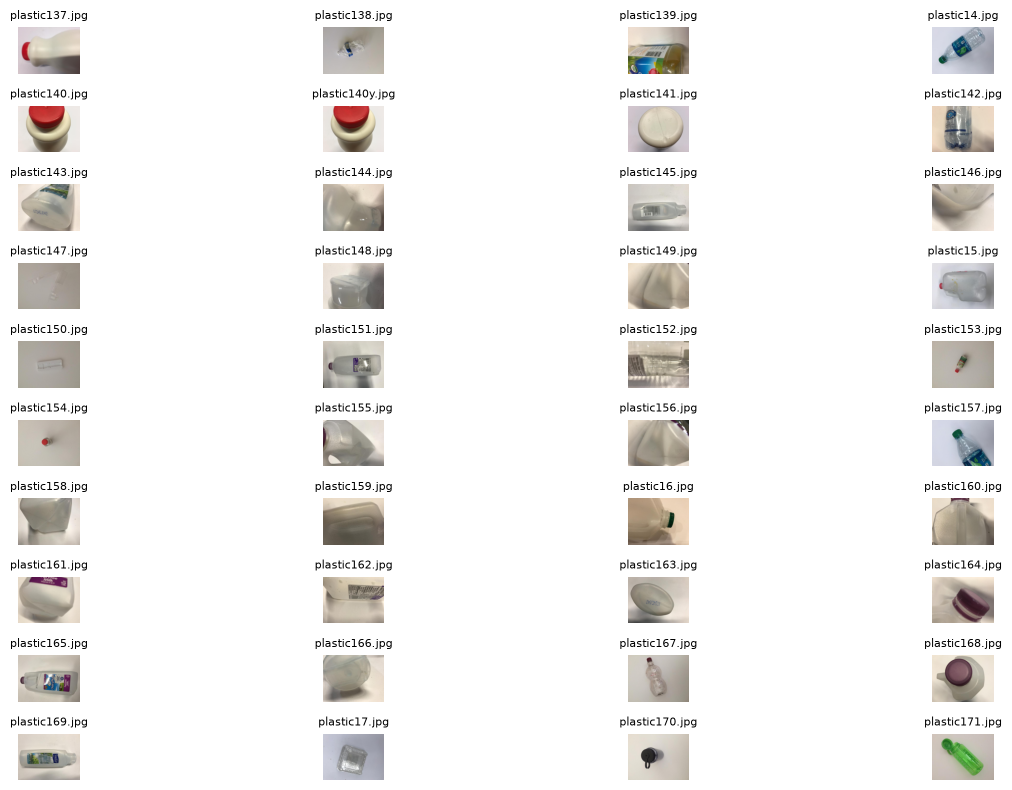

In [159]:
# ÉTAPE 1 : choisir la classe et la page à regarder
classe = "plastic"
page = 1            # 0 = première page, 1 = deuxième page, etc.
par_page = 40       # nombre d'images affichées à la fois

# ÉTAPE 2 : sélectionner les images de cette classe (sans les corrompues)
images_classe = df[(df["class"] == classe) & (df["is_corrupted_image"] == False)]
print(len(images_classe), "images, soit", math.ceil(len(images_classe) / par_page), "pages")

# ÉTAPE 3 : garder seulement les 12 images de la page choisie
debut = page * par_page
fin = debut + par_page
lot = images_classe.iloc[debut:fin]

# ÉTAPE 4 : afficher ces images dans une grille de 3 lignes × 4 colonnes
plt.figure(figsize=(14, 8))
for numero, (i, ligne) in enumerate(lot.iterrows()):
    plt.subplot(10, 4, numero + 1)
    plt.imshow(Image.open(fichiers[i]).convert("RGB"))
    plt.title(ligne["name"], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
MAL_CLASSEES = {
    "cardboard/cardboard161.jpg": "glass",
    "cardboard/cardboard72.jpg": "remove",
    "cardboard/cardboard9.jpg": "plastic",
    "cardboard/image-blanche-512x384.jpg": "blanc",
    "cardboard/image-violet-512x384.gif": "blanc",
    "glass/glass12er.jpg": "paper",
    "metal/image-blanche-512x384.jpg": "blanche",
    "metal/image-noire-512x384.png": "noire",
    "metal/metal150.jpg": "cardboard",
    "paper/paper201.jpg": "glass",
    "plastic/plastic112.jpg": "glass",

}

# Partie 8 : Analyser le déséquilibre des classes
Déterminer le nombre d'images par classe

           n_fichiers  n_lisibles  proportion_%
class                                          
paper             252         251         24.46
plastic           224         223         21.73
glass             188         187         18.23
cardboard         169         168         16.37
metal             149         148         14.42
trash              50          49          4.78

Classe majoritaire : paper (251 images)
Classe minoritaire : trash (49 images)
Ratio de déséquilibre : 5.12


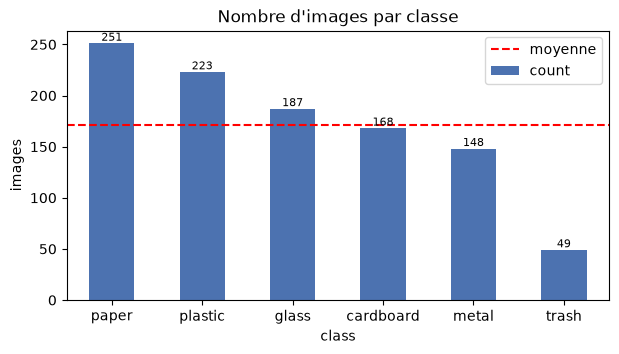

KeyError: 'is_corrupted'

In [175]:
# ÉTAPE 1 : nombre d'images par classe
compte_tous = df["class"].value_counts()                                # tous les fichiers
compte_lisibles = df[~df["is_corrupted_image"]]["class"].value_counts()      # fichiers lisibles seulement

tableau = pd.DataFrame({
    "n_fichiers": compte_tous,
    "n_lisibles": compte_lisibles,
    "proportion_%": (100 * compte_lisibles / compte_lisibles.sum()).round(2),
})
print(tableau)

# ÉTAPE 2 : mesure du déséquilibre
majoritaire = compte_lisibles.idxmax()
minoritaire = compte_lisibles.idxmin()
ratio = compte_lisibles.max() / compte_lisibles.min()

print(f"\nClasse majoritaire : {majoritaire} ({compte_lisibles.max()} images)")
print(f"Classe minoritaire : {minoritaire} ({compte_lisibles.min()} images)")
print(f"Ratio de déséquilibre : {ratio:.2f}")


CLASSES = compte_lisibles.index.tolist()

# ÉTAPE 3 : graphique
ax = compte_lisibles.reindex(CLASSES).plot.bar(rot=0, color="#4C72B0", figsize=(7, 3.5))
for i, v in enumerate(compte_lisibles.reindex(CLASSES)):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=8)     # valeur au-dessus des barres
ax.axhline(compte_lisibles.mean(), color="red", linestyle="--", label="moyenne")
ax.set_title("Nombre d'images par classe")
ax.set_ylabel("images")
ax.legend()
plt.show()

# ÉTAPE 4 : générer reports/audit_images.csv
audit = pd.DataFrame({
    "indicateur": ["Total d'images", "Images corrompues", "Images quasi vides", "Images trop petites",
                   "Doublons", "Images grayscale", "Images RGBA", "Images mal classées"],
    "valeur": [len(df), int(df["is_corrupted"].sum()), int(df["is_empty"].sum()), int(df["too_small"].sum()),
               int(df["is_duplicate"].sum()), int(df["is_grayscale"].sum()), int(df["is_rgba"].sum()),
               len(MAL_CLASSEES)],
})
audit["pourcentage_du_total"] = (100 * audit["valeur"] / len(df)).round(2)

audit.to_csv(REPORTS_DIR / "audit_images.csv", index=False, encoding="utf-8-sig")
print(audit)